# 047. Breast Cancer Classification and Segmentation Using Deep Learning on Ultrasound Images

**Dataset:** Breast Ultrasound Images (BUSI) — Baheya Hospital, Cairo, Egypt  
**Tasks:** Preprocessing → Augmentation → Train/Val/Test split → Classification (ResNet18) → Segmentation (U-Net)

**Environment:** `conda activate 9444_clean`

## 1. Imports & Configuration

In [2]:
import json
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

%matplotlib inline
sns.set_theme(style="whitegrid")

# Paths (notebook lives in project root)
ROOT = Path.cwd()
DATA_DIR = ROOT / "Dataset_BUSI_with_GT"
OUTPUT_DIR = ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
SPLIT_DIR = OUTPUT_DIR / "splits"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, FIGURE_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["benign", "malignant", "normal"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Shared
SEED = 42
IMG_SIZE = 224
NUM_WORKERS = 0
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Classification
CLS_BATCH_SIZE = 32
CLS_EPOCHS = 15
CLS_LR = 1e-4
CLS_WEIGHT_DECAY = 1e-4
CLS_MODEL = "resnet18"  # resnet18 | densenet121 | efficientnet_b0

# Segmentation
SEG_BATCH_SIZE = 16
SEG_EPOCHS = 20
SEG_LR = 1e-4
SEG_WEIGHT_DECAY = 1e-4
SEG_INCLUDE_NORMAL = False

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT={ROOT}")
print(f"Device={DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU={torch.cuda.get_device_name(0)}")

ROOT=/Users/alyannazhang/Desktop/9414prj
Device=cpu


## 2. Utilities (metrics & plotting)

In [4]:
def plot_history(history: Dict[str, List[float]], title: str, ylabel: str = "value", out_path: Path | None = None):
    plt.figure(figsize=(8, 5))
    for key, values in history.items():
        plt.plot(range(1, len(values) + 1), values, label=key, marker="o", markersize=3)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix", out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


def classification_metrics(y_true, y_pred, class_names):
    report = classification_report(
        y_true, y_pred, target_names=list(class_names), digits=4, zero_division=0, output_dict=True
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "report": report,
    }

## 3. Dataset: discovery, preprocessing, augmentation, split

- Pair each ultrasound image with its ground-truth mask(s) (OR-merge multi-masks)
- Stratified **70% / 15% / 15%** train / val / test split
- Classification augmentations: flip, rotation, brightness/contrast
- Segmentation: paired geometric augmentations on image + mask

In [6]:
@dataclass
class Sample:
    image_path: Path
    mask_paths: List[Path]
    label: int
    class_name: str


def discover_samples(data_dir: Path = DATA_DIR) -> List[Sample]:
    samples: List[Sample] = []
    for class_name in CLASS_NAMES:
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")
        images = sorted(p for p in class_dir.glob("*.png") if "_mask" not in p.name)
        for img_path in images:
            stem = img_path.stem
            mask_paths = sorted(class_dir.glob(f"{stem}_mask*.png"))
            if not mask_paths:
                continue
            samples.append(
                Sample(
                    image_path=img_path,
                    mask_paths=mask_paths,
                    label=CLASS_TO_IDX[class_name],
                    class_name=class_name,
                )
            )
    return samples


def stratified_split(samples: List[Sample], seed: int = SEED) -> Dict[str, List[Sample]]:
    labels = [s.label for s in samples]
    train_val, test = train_test_split(samples, test_size=TEST_RATIO, random_state=seed, stratify=labels)
    val_ratio_adj = VAL_RATIO / (1.0 - TEST_RATIO)
    labels_tv = [s.label for s in train_val]
    train, val = train_test_split(train_val, test_size=val_ratio_adj, random_state=seed, stratify=labels_tv)
    return {"train": train, "val": val, "test": test}


def save_split(split: Dict[str, List[Sample]], out_dir: Path = SPLIT_DIR) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        split_name: [
            {
                "image": str(s.image_path),
                "masks": [str(m) for m in s.mask_paths],
                "label": s.label,
                "class_name": s.class_name,
            }
            for s in items
        ]
        for split_name, items in split.items()
    }
    path = out_dir / "split.json"
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def load_split(path: Path = SPLIT_DIR / "split.json") -> Dict[str, List[Sample]]:
    payload = json.loads(path.read_text(encoding="utf-8"))
    return {
        split_name: [
            Sample(
                image_path=Path(item["image"]),
                mask_paths=[Path(m) for m in item["masks"]],
                label=item["label"],
                class_name=item["class_name"],
            )
            for item in items
        ]
        for split_name, items in payload.items()
    }


def load_rgb(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def load_combined_mask(mask_paths: List[Path], size: Tuple[int, int]) -> Image.Image:
    combined = np.zeros((size[1], size[0]), dtype=np.uint8)
    for mp in mask_paths:
        m = np.array(Image.open(mp).convert("L").resize(size, Image.NEAREST))
        combined = np.maximum(combined, (m > 127).astype(np.uint8) * 255)
    return Image.fromarray(combined, mode="L")


class ClassificationAugment:
    def __init__(self, img_size: int = IMG_SIZE):
        self.train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.eval_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, image: Image.Image, train: bool) -> torch.Tensor:
        return self.train_tf(image) if train else self.eval_tf(image)


class SegmentationAugment:
    def __init__(self, img_size: int = IMG_SIZE, train: bool = True):
        self.img_size = img_size
        self.train = train
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, image: Image.Image, mask: Image.Image) -> Tuple[torch.Tensor, torch.Tensor]:
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        if self.train:
            if random.random() < 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() < 0.2:
                image = image.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-15, 15)
            image = image.rotate(angle, resample=Image.BILINEAR)
            mask = mask.rotate(angle, resample=Image.NEAREST)
            if random.random() < 0.5:
                image = transforms.functional.adjust_brightness(image, random.uniform(0.8, 1.2))
            if random.random() < 0.5:
                image = transforms.functional.adjust_contrast(image, random.uniform(0.8, 1.2))
        img_t = self.normalize(transforms.functional.to_tensor(image))
        mask_t = torch.from_numpy((np.array(mask) > 127).astype(np.float32)).unsqueeze(0)
        return img_t, mask_t


class BUSIClassificationDataset(Dataset):
    def __init__(self, samples: List[Sample], train: bool = False):
        self.samples = samples
        self.train = train
        self.augment = ClassificationAugment()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return self.augment(load_rgb(s.image_path), train=self.train), s.label


class BUSISegmentationDataset(Dataset):
    def __init__(self, samples: List[Sample], train: bool = False, include_normal: bool = SEG_INCLUDE_NORMAL):
        self.samples = samples if include_normal else [s for s in samples if s.class_name != "normal"]
        self.train = train
        self.augment = SegmentationAugment(train=train)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = load_rgb(s.image_path)
        mask = load_combined_mask(s.mask_paths, image.size)
        return self.augment(image, mask)

### Explore dataset & create split

Total samples: 780
Class counts: {'benign': 437, 'malignant': 210, 'normal': 133}


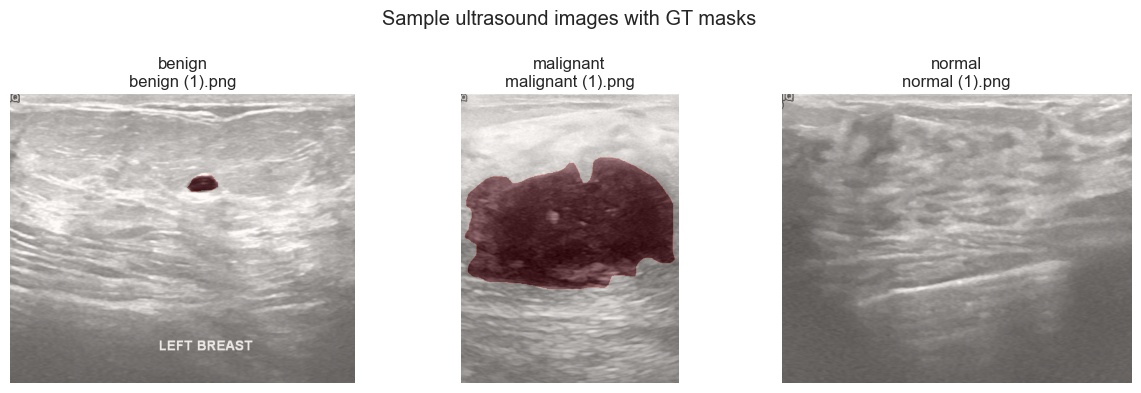

Loaded existing split from /Users/alyannazhang/Desktop/9414prj/outputs/splits/split.json
  train: 545 -> {'benign': 305, 'malignant': 147, 'normal': 93}
  val: 118 -> {'benign': 66, 'normal': 20, 'malignant': 32}
  test: 117 -> {'benign': 66, 'malignant': 31, 'normal': 20}


In [7]:
samples = discover_samples()
print(f"Total samples: {len(samples)}")
print("Class counts:", dict(Counter(s.class_name for s in samples)))

# Show one example per class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, class_name in zip(axes, CLASS_NAMES):
    s = next(x for x in samples if x.class_name == class_name)
    img = load_rgb(s.image_path)
    mask = load_combined_mask(s.mask_paths, img.size)
    ax.imshow(img)
    ax.imshow(np.array(mask), cmap="Reds", alpha=0.35)
    ax.set_title(f"{class_name}\n{s.image_path.name}")
    ax.axis("off")
plt.suptitle("Sample ultrasound images with GT masks")
plt.tight_layout()
plt.show()

split_path = SPLIT_DIR / "split.json"
if split_path.exists():
    split = load_split(split_path)
    print(f"Loaded existing split from {split_path}")
else:
    split = stratified_split(samples)
    save_split(split)
    print(f"Created new split -> {split_path}")

for name, items in split.items():
    print(f"  {name}: {len(items)} -> {dict(Counter(s.class_name for s in items))}")

## 4. Models: Classifier (ResNet/DenseNet/EfficientNet) + U-Net

In [8]:
def build_classifier(name: str = "resnet18", num_classes: int = 3) -> nn.Module:
    name = name.lower()
    if name == "resnet18":
        try:
            weights = models.ResNet18_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.resnet18(weights=weights)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        return backbone
    if name == "densenet121":
        try:
            weights = models.DenseNet121_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.densenet121(weights=weights)
        backbone.classifier = nn.Linear(backbone.classifier.in_features, num_classes)
        return backbone
    if name in {"efficientnet_b0", "efficientnet-b0"}:
        try:
            weights = models.EfficientNet_B0_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.efficientnet_b0(weights=weights)
        backbone.classifier[1] = nn.Linear(backbone.classifier[1].in_features, num_classes)
        return backbone
    raise ValueError(f"Unsupported classifier: {name}")


class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base: int = 32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.enc4 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = ConvBlock(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        dims = (0, 2, 3)
        intersection = (probs * targets).sum(dim=dims)
        union = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice = 1.0 - (2.0 * intersection + self.smooth) / (union + self.smooth)
        return bce + dice.mean()


def dice_coefficient(logits, targets, threshold: float = 0.5, eps: float = 1e-7) -> float:
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * targets).sum().item()
    denom = preds.sum().item() + targets.sum().item()
    return float((2.0 * inter + eps) / (denom + eps))


def iou_score(logits, targets, threshold: float = 0.5, eps: float = 1e-7) -> float:
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * targets).sum().item()
    union = preds.sum().item() + targets.sum().item() - inter
    return float((inter + eps) / (union + eps))

print("Classifier:", CLS_MODEL)
print(build_classifier(CLS_MODEL))
print("\nU-Net params:", sum(p.numel() for p in UNet().parameters()) / 1e6, "M")

Classifier: resnet18
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=Tr

In [13]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),            
            nn.Dropout(0.25),         
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),  
        )

    def forward(self, x):
        return self.classifier(self.features(x))

_test = CNNClassifier()
print(_test(torch.randn(2, 3, 224, 224)).shape) 
print("params:", sum(p.numel() for p in _test.parameters()) / 1e6, "M")

torch.Size([2, 3])
params: 1.206499 M


## 5. Classification Training (ResNet18 -> benign / malignant / normal)

In [15]:
CLS_EPOCHS = 40
CLS_LR = 3e-4

def make_cls_loaders(split):
    datasets = {
        "train": BUSIClassificationDataset(split["train"], train=True),
        "val": BUSIClassificationDataset(split["val"], train=False),
        "test": BUSIClassificationDataset(split["test"], train=False),
    }
    return {
        name: DataLoader(
            ds,
            batch_size=CLS_BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
        for name, ds in datasets.items()
    }


@torch.no_grad()
def evaluate_cls(model, loader, criterion):
    model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * images.size(0)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    acc = sum(int(a == b) for a, b in zip(y_true, y_pred)) / max(len(y_true), 1)
    return avg_loss, acc, y_true, y_pred


set_seed(SEED)
cls_loaders = make_cls_loaders(split)
print(f"[Classification] train={len(split['train'])} val={len(split['val'])} test={len(split['test'])}")

cls_model = CNNClassifier(num_classes=len(CLASS_NAMES)).to(DEVICE)

train_labels = [s.label for s in split["train"]]
class_counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))
class_weights = torch.tensor(
    len(train_labels) / (len(CLASS_NAMES) * class_counts),
    dtype=torch.float32, device=DEVICE,
)
print("class weights:", class_weights)
cls_criterion = nn.CrossEntropyLoss(weight=class_weights)

cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=CLS_LR, weight_decay=CLS_WEIGHT_DECAY)
cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=CLS_EPOCHS)

cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1.0

best_cls_path = CHECKPOINT_DIR / "best_cnn_classifier.pth"

for epoch in range(1, CLS_EPOCHS + 1):
    cls_model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(cls_loaders["train"], desc=f"Cls Epoch {epoch}/{CLS_EPOCHS}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        cls_optimizer.zero_grad()
        logits = cls_model(images)
        loss = cls_criterion(logits, labels)
        loss.backward()
        cls_optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct / max(total, 1))

    cls_scheduler.step()
    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)
    val_loss, val_acc, _, _ = evaluate_cls(cls_model, cls_loaders["val"], cls_criterion)
    cls_history["train_loss"].append(train_loss)
    cls_history["val_loss"].append(val_loss)
    cls_history["train_acc"].append(train_acc)
    cls_history["val_acc"].append(val_acc)
    print(f"  train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_name": "custom_cnn",
                "state_dict": cls_model.state_dict(),
                "val_acc": best_val_acc,
                "epoch": epoch,
                "class_names": CLASS_NAMES,
            },
            best_cls_path,
        )
        print(f"  saved best classifier (val_acc={best_val_acc:.4f})")

[Classification] train=545 val=118 test=117
class weights: tensor([0.5956, 1.2358, 1.9534])


Cls Epoch 1/40:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=1.0827 train_acc=0.3817 | val_loss=1.1789 val_acc=0.2712
  saved best classifier (val_acc=0.2712)


Cls Epoch 2/40:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=1.0404 train_acc=0.5119 | val_loss=0.9539 val_acc=0.3983
  saved best classifier (val_acc=0.3983)


...

  train_loss=0.5306 train_acc=0.7651 | val_loss=0.7119 val_acc=0.7203


Cls Epoch 39/40:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.5570 train_acc=0.7596 | val_loss=0.6959 val_acc=0.7034


Cls Epoch 40/40:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.5455 train_acc=0.7394 | val_loss=0.7083 val_acc=0.6695


In [10]:
def make_cls_loaders(split):
    datasets = {
        "train": BUSIClassificationDataset(split["train"], train=True),
        "val": BUSIClassificationDataset(split["val"], train=False),
        "test": BUSIClassificationDataset(split["test"], train=False),
    }
    return {
        name: DataLoader(
            ds,
            batch_size=CLS_BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
        for name, ds in datasets.items()
    }


@torch.no_grad()
def evaluate_cls(model, loader, criterion):
    model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * images.size(0)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    acc = sum(int(a == b) for a, b in zip(y_true, y_pred)) / max(len(y_true), 1)
    return avg_loss, acc, y_true, y_pred


set_seed(SEED)
cls_loaders = make_cls_loaders(split)
print(f"[Classification] train={len(split['train'])} val={len(split['val'])} test={len(split['test'])}")

cls_model = build_classifier(CLS_MODEL, num_classes=len(CLASS_NAMES)).to(DEVICE)
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=CLS_LR, weight_decay=CLS_WEIGHT_DECAY)
cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=CLS_EPOCHS)

cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1.0
best_cls_path = CHECKPOINT_DIR / "best_classifier.pth"

for epoch in range(1, CLS_EPOCHS + 1):
    cls_model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(cls_loaders["train"], desc=f"Cls Epoch {epoch}/{CLS_EPOCHS}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        cls_optimizer.zero_grad()
        logits = cls_model(images)
        loss = cls_criterion(logits, labels)
        loss.backward()
        cls_optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct / max(total, 1))

    cls_scheduler.step()
    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)
    val_loss, val_acc, _, _ = evaluate_cls(cls_model, cls_loaders["val"], cls_criterion)
    cls_history["train_loss"].append(train_loss)
    cls_history["val_loss"].append(val_loss)
    cls_history["train_acc"].append(train_acc)
    cls_history["val_acc"].append(val_acc)
    print(f"  train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_name": CLS_MODEL,
                "state_dict": cls_model.state_dict(),
                "val_acc": best_val_acc,
                "epoch": epoch,
                "class_names": CLASS_NAMES,
            },
            best_cls_path,
        )
        print(f"  saved best classifier (val_acc={best_val_acc:.4f})")

[Classification] train=545 val=118 test=117


Cls Epoch 1/15:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.8448 train_acc=0.5963 | val_loss=0.7390 val_acc=0.6695
  saved best classifier (val_acc=0.6695)


Cls Epoch 2/15:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.5712 train_acc=0.7596 | val_loss=0.5216 val_acc=0.8475
  saved best classifier (val_acc=0.8475)


...

  train_loss=0.1293 train_acc=0.9560 | val_loss=0.3883 val_acc=0.8898


Cls Epoch 14/15:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.1276 train_acc=0.9578 | val_loss=0.3985 val_acc=0.8898


Cls Epoch 15/15:   0%|          | 0/18 [00:00<?, ?it/s]

  train_loss=0.1145 train_acc=0.9615 | val_loss=0.3794 val_acc=0.8729


### Classification evaluation

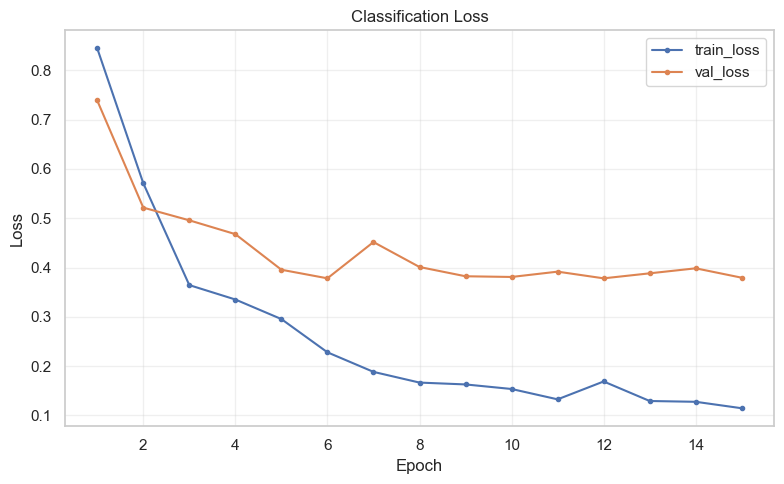

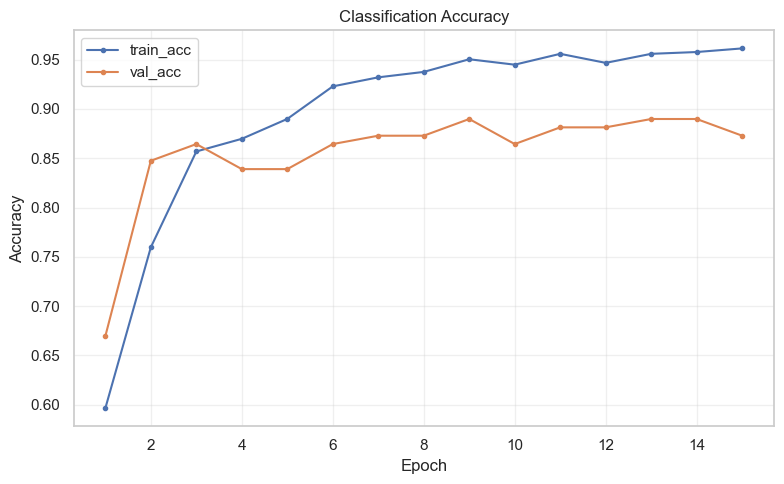

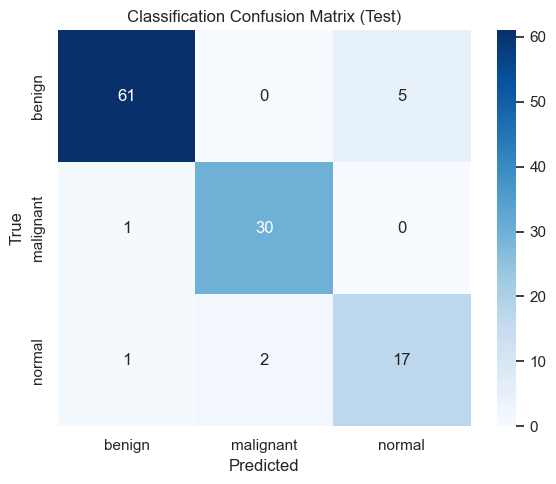

              precision    recall  f1-score   support

      benign     0.9683    0.9242    0.9457        66
   malignant     0.9375    0.9677    0.9524        31
      normal     0.7727    0.8500    0.8095        20

    accuracy                         0.9231       117
   macro avg     0.8928    0.9140    0.9025       117
weighted avg     0.9267    0.9231    0.9242       117

TEST accuracy=0.9231 | macro_f1=0.9025


2719

In [7]:
plot_history(
    {"train_loss": cls_history["train_loss"], "val_loss": cls_history["val_loss"]},
    "Classification Loss", ylabel="Loss", out_path=FIGURE_DIR / "classification_loss.png",
)
plot_history(
    {"train_acc": cls_history["train_acc"], "val_acc": cls_history["val_acc"]},
    "Classification Accuracy", ylabel="Accuracy", out_path=FIGURE_DIR / "classification_accuracy.png",
)

ckpt = torch.load(best_cls_path, map_location=DEVICE, weights_only=False)
cls_model.load_state_dict(ckpt["state_dict"])
test_loss, test_acc, y_true, y_pred = evaluate_cls(cls_model, cls_loaders["test"], cls_criterion)
cls_metrics = classification_metrics(y_true, y_pred, CLASS_NAMES)
plot_confusion(
    y_true, y_pred, CLASS_NAMES,
    title="Classification Confusion Matrix (Test)",
    out_path=FIGURE_DIR / "classification_confusion.png",
)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f"TEST accuracy={cls_metrics['accuracy']:.4f} | macro_f1={cls_metrics['macro_f1']:.4f}")

cls_results = {
    "best_val_acc": best_val_acc,
    "test_loss": test_loss,
    "test_accuracy": cls_metrics["accuracy"],
    "macro_f1": cls_metrics["macro_f1"],
    "weighted_f1": cls_metrics["weighted_f1"],
    "classification_report": cls_metrics["report"],
    "history": cls_history,
}
(OUTPUT_DIR / "classification_results.json").write_text(json.dumps(cls_results, indent=2), encoding="utf-8")

## 6. Segmentation Training (U-Net on benign + malignant masks)

In [8]:
def make_seg_loaders(split):
    datasets = {
        "train": BUSISegmentationDataset(split["train"], train=True, include_normal=SEG_INCLUDE_NORMAL),
        "val": BUSISegmentationDataset(split["val"], train=False, include_normal=SEG_INCLUDE_NORMAL),
        "test": BUSISegmentationDataset(split["test"], train=False, include_normal=SEG_INCLUDE_NORMAL),
    }
    return {
        name: DataLoader(
            ds,
            batch_size=SEG_BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
        for name, ds in datasets.items()
    }


@torch.no_grad()
def evaluate_seg(model, loader, criterion):
    model.eval()
    total_loss, dice_sum, iou_sum, n = 0.0, 0.0, 0.0, 0
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        bs = images.size(0)
        total_loss += criterion(logits, masks).item() * bs
        dice_sum += dice_coefficient(logits, masks) * bs
        iou_sum += iou_score(logits, masks) * bs
        n += bs
    return total_loss / max(n, 1), dice_sum / max(n, 1), iou_sum / max(n, 1)


@torch.no_grad()
def show_seg_examples(model, loader, max_samples: int = 6, out_path: Path | None = None):
    model.eval()
    images, masks = next(iter(loader))
    images = images[:max_samples].to(DEVICE)
    masks = masks[:max_samples]
    preds = (torch.sigmoid(model(images)) > 0.5).float().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    imgs = (images.cpu() * std + mean).clamp(0, 1)
    n = imgs.size(0)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    for i in range(n):
        axes[i, 0].imshow(imgs[i].permute(1, 2, 0).numpy()); axes[i, 0].set_title("Image"); axes[i, 0].axis("off")
        axes[i, 1].imshow(masks[i, 0].numpy(), cmap="gray"); axes[i, 1].set_title("GT Mask"); axes[i, 1].axis("off")
        axes[i, 2].imshow(preds[i, 0].numpy(), cmap="gray"); axes[i, 2].set_title("Prediction"); axes[i, 2].axis("off")
    plt.tight_layout()
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


set_seed(SEED)
seg_loaders = make_seg_loaders(split)
print(
    f"[Segmentation] train={len(seg_loaders['train'].dataset)} "
    f"val={len(seg_loaders['val'].dataset)} test={len(seg_loaders['test'].dataset)}"
)

seg_model = UNet(in_channels=3, out_channels=1, base=32).to(DEVICE)
seg_criterion = DiceBCELoss()
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=SEG_LR, weight_decay=SEG_WEIGHT_DECAY)
seg_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(seg_optimizer, T_max=SEG_EPOCHS)

seg_history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": [], "val_iou": []}
best_val_dice = -1.0
best_seg_path = CHECKPOINT_DIR / "best_unet.pth"

for epoch in range(1, SEG_EPOCHS + 1):
    seg_model.train()
    running_loss, running_dice, total = 0.0, 0.0, 0
    pbar = tqdm(seg_loaders["train"], desc=f"Seg Epoch {epoch}/{SEG_EPOCHS}")
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        seg_optimizer.zero_grad()
        logits = seg_model(images)
        loss = seg_criterion(logits, masks)
        loss.backward()
        seg_optimizer.step()
        bs = images.size(0)
        running_loss += loss.item() * bs
        batch_dice = dice_coefficient(logits.detach(), masks)
        running_dice += batch_dice * bs
        total += bs
        pbar.set_postfix(loss=loss.item(), dice=batch_dice)

    seg_scheduler.step()
    train_loss = running_loss / max(total, 1)
    train_dice = running_dice / max(total, 1)
    val_loss, val_dice, val_iou = evaluate_seg(seg_model, seg_loaders["val"], seg_criterion)
    seg_history["train_loss"].append(train_loss)
    seg_history["val_loss"].append(val_loss)
    seg_history["train_dice"].append(train_dice)
    seg_history["val_dice"].append(val_dice)
    seg_history["val_iou"].append(val_iou)
    print(
        f"  train_loss={train_loss:.4f} train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_iou={val_iou:.4f}"
    )
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({"state_dict": seg_model.state_dict(), "val_dice": best_val_dice, "epoch": epoch}, best_seg_path)
        print(f"  saved best U-Net (val_dice={best_val_dice:.4f})")

[Segmentation] train=452 val=98 test=97


Seg Epoch 1/20:   0%|          | 0/29 [00:00<?, ?it/s]

### Segmentation evaluation

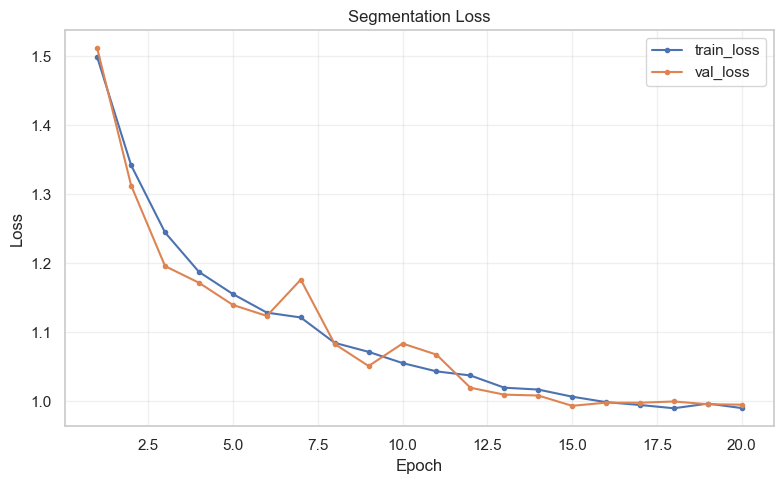

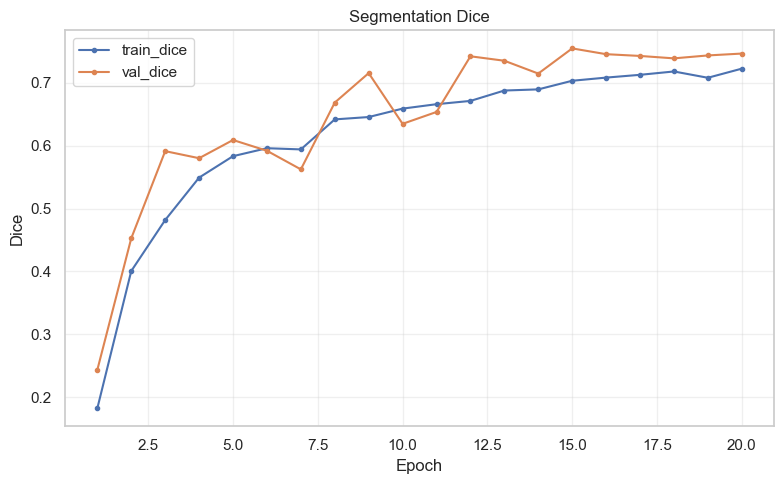

TEST dice=0.7069 | iou=0.5526


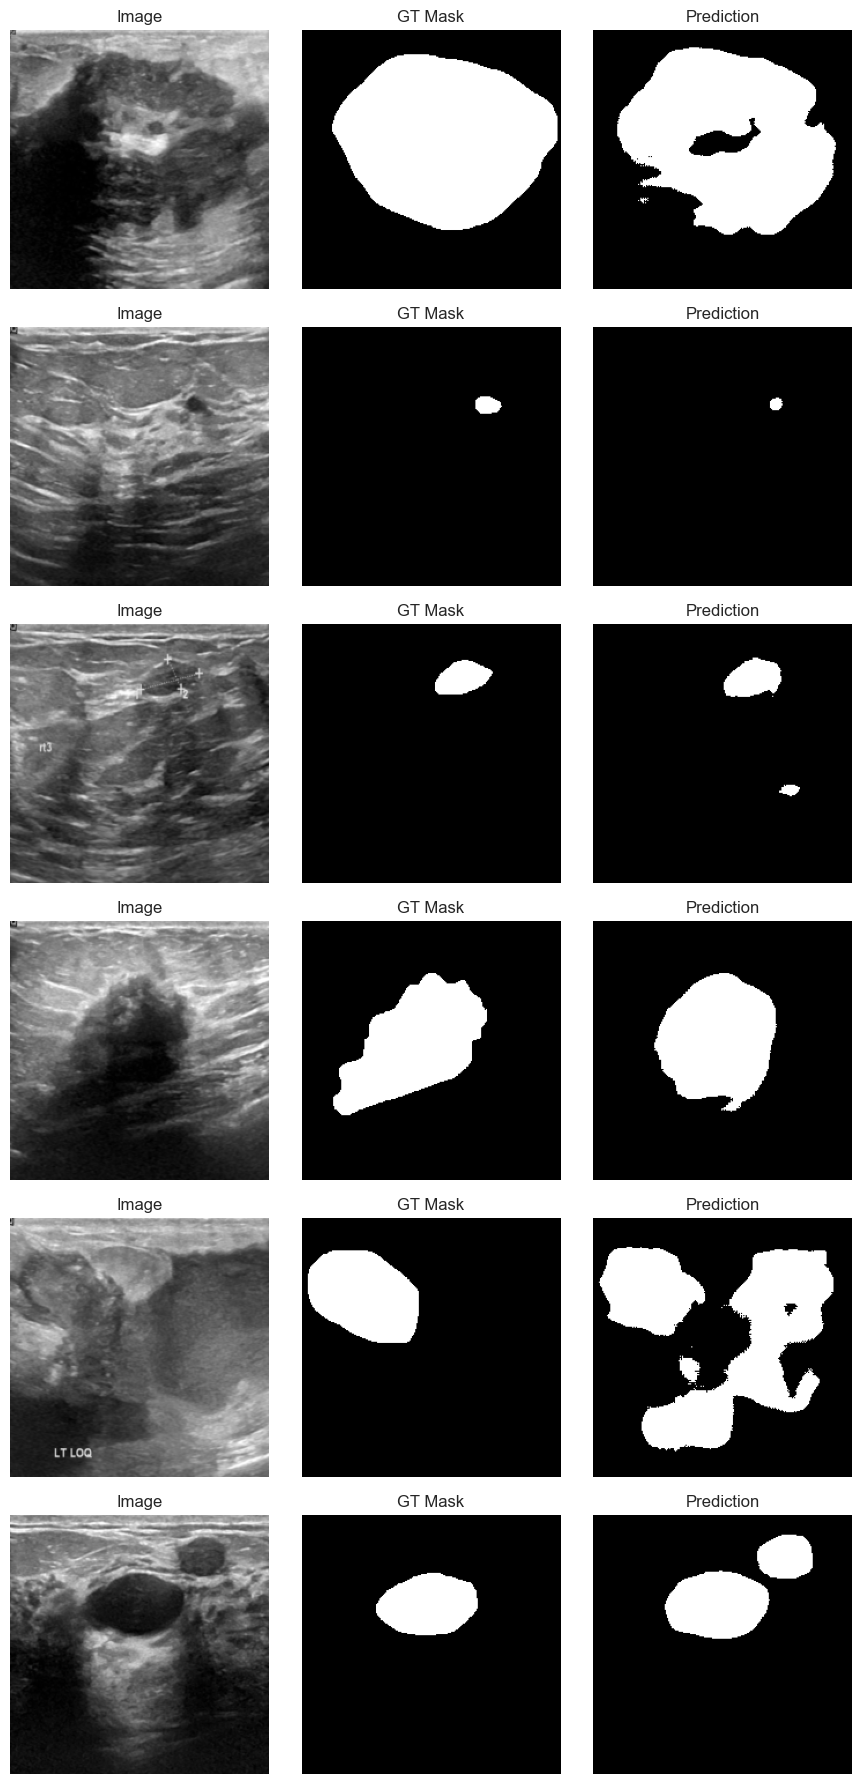

2885

In [ ]:
plot_history(
    {"train_loss": seg_history["train_loss"], "val_loss": seg_history["val_loss"]},
    "Segmentation Loss", ylabel="Loss", out_path=FIGURE_DIR / "segmentation_loss.png",
)
plot_history(
    {"train_dice": seg_history["train_dice"], "val_dice": seg_history["val_dice"]},
    "Segmentation Dice", ylabel="Dice", out_path=FIGURE_DIR / "segmentation_dice.png",
)

ckpt = torch.load(best_seg_path, map_location=DEVICE, weights_only=False)
seg_model.load_state_dict(ckpt["state_dict"])
test_loss, test_dice, test_iou = evaluate_seg(seg_model, seg_loaders["test"], seg_criterion)
print(f"TEST dice={test_dice:.4f} | iou={test_iou:.4f}")
show_seg_examples(seg_model, seg_loaders["test"], out_path=FIGURE_DIR / "segmentation_examples.png")

seg_results = {
    "best_val_dice": best_val_dice,
    "test_loss": test_loss,
    "test_dice": test_dice,
    "test_iou": test_iou,
    "history": seg_history,
}
(OUTPUT_DIR / "segmentation_results.json").write_text(json.dumps(seg_results, indent=2), encoding="utf-8")

## 7. Inference Demo

=== Classification demo ===
Image: C:\Users\user\Desktop\9444prj\Dataset_BUSI_with_GT\benign\benign (404).png
  benign    : 0.9486
  malignant : 0.0493
  normal    : 0.0021
Prediction: benign
Image: C:\Users\user\Desktop\9444prj\Dataset_BUSI_with_GT\malignant\malignant (19).png
  benign    : 0.0001
  malignant : 0.9999
  normal    : 0.0000
Prediction: malignant

=== Segmentation demo ===


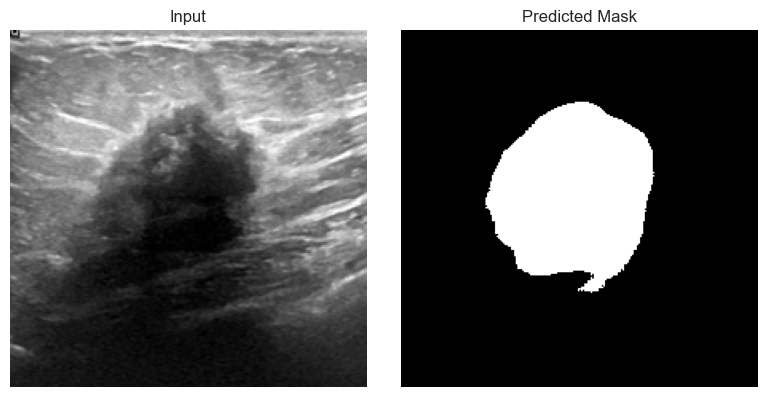

In [ ]:
def predict_class(image_path: Path, ckpt_path: Path = best_cls_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = build_classifier(ckpt.get("model_name", CLS_MODEL), num_classes=3)
    model.load_state_dict(ckpt["state_dict"])
    model.to(DEVICE).eval()
    x = ClassificationAugment()(load_rgb(image_path), train=False).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    pred = int(probs.argmax().item())
    print(f"Image: {image_path}")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name:10s}: {probs[i].item():.4f}")
    print(f"Prediction: {CLASS_NAMES[pred]}")
    return CLASS_NAMES[pred]


def predict_mask(image_path: Path, ckpt_path: Path = best_seg_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = UNet().to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    image = load_rgb(image_path)
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    x = tf(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = (torch.sigmoid(model(x)) > 0.5).float().cpu()[0, 0].numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(pred, cmap="gray"); axes[1].set_title("Predicted Mask"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()


# Demo on one benign / malignant sample
demo_benign = next(s for s in split["test"] if s.class_name == "benign").image_path
demo_malignant = next(s for s in split["test"] if s.class_name == "malignant").image_path

print("=== Classification demo ===")
predict_class(demo_benign)
predict_class(demo_malignant)

print("\n=== Segmentation demo ===")
predict_mask(demo_malignant)

## Summary

| Task | Model | Metric | Typical result |
|------|-------|--------|----------------|
| Classification | ResNet18 | Test Accuracy / Macro-F1 | ~0.89 / ~0.88 |
| Segmentation | U-Net | Test Dice / IoU | ~0.72 / ~0.57 |

Artifacts are saved under `outputs/` (checkpoints, figures, JSON metrics).